In [1]:
!pip install yfinance pandas matplotlib plotly streamlit scikit-learn

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Download Apple stock data for the last 2 years
stock = yf.download("AAPL", start="2022-01-01", end="2024-12-31")

# Look at the first 5 rows
stock.head()

C:\Users\91848\AppData\Local\Temp\ipykernel_23448\2651340153.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103653,178.954991,173.895953,174.013372,104487900
2022-01-04,175.843277,179.013745,175.275723,178.710401,99310400
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600
2022-01-06,168.308502,171.537680,167.956228,168.993476,96904000
2022-01-07,168.474838,170.402559,167.359306,169.179387,86709100


In [7]:
# How many rows and columns do we have?
print("Shape:", stock.shape)

# What are the column names?
print("Columns:", stock.columns.tolist())

# Any missing values?
print("Missing values:\n", stock.isnull().sum())

# Basic statistics
stock.describe()

Shape: (752, 5)
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]
Missing values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,175.930895,177.602214,174.054117,175.737404,6.811545e+07
std,29.379630,29.301144,29.325771,29.304615,2.834590e+07
min,123.046822,125.753419,122.210227,124.021194,2.323470e+07
25%,153.364716,155.061740,151.123563,152.832386,4.877432e+07
50%,171.176865,172.192410,169.396991,170.829554,6.224455e+07
75%,189.577972,190.982793,188.283294,189.460061,8.059140e+07
max,257.612701,258.686851,256.230269,256.787224,3.186799e+08


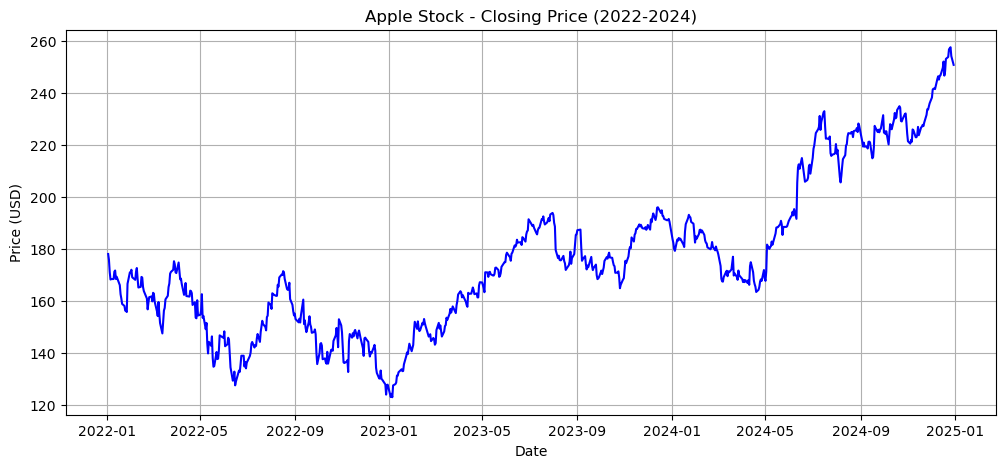

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(stock["Close"], color="blue")
plt.title("Apple Stock - Closing Price (2022-2024)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

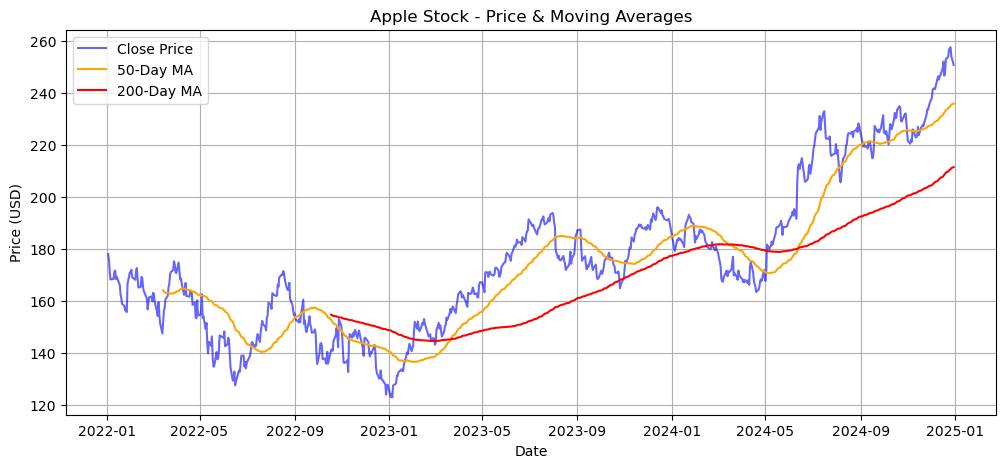

In [11]:
# Calculate 50-day and 200-day moving averages
stock["MA50"] = stock["Close"].rolling(window=50).mean()
stock["MA200"] = stock["Close"].rolling(window=200).mean()

# Plot all three together
plt.figure(figsize=(12, 5))
plt.plot(stock["Close"], label="Close Price", color="blue", alpha=0.6)
plt.plot(stock["MA50"], label="50-Day MA", color="orange")
plt.plot(stock["MA200"], label="200-Day MA", color="red")
plt.title("Apple Stock - Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Flatten multi-level columns from yfinance
stock.columns = stock.columns.get_level_values(0)

# Confirm it worked
print(stock.columns)


Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA50', 'MA200', 'Tomorrow'], dtype='object', name='Price')


In [21]:
# Create a new column - 1 if price went up next day, 0 if it went down
stock["Tomorrow"] = stock["Close"].shift(-1)
stock["Target"] = (stock["Tomorrow"] > stock["Close"]).astype(int)

# Check it
stock[["Close", "Tomorrow", "Target"]].head(10)

Price,Close,Tomorrow,Target
Date,,,
2022-01-03,178.103653,175.843277,0
2022-01-04,175.843277,171.165817,0
2022-01-05,171.165817,168.308502,0
2022-01-06,168.308502,168.474838,1
2022-01-07,168.474838,168.494446,1
2022-01-10,168.494446,171.322418,1
2022-01-11,171.322418,171.762711,1
2022-01-12,171.762711,168.494446,0
2022-01-13,168.494446,169.355576,1


In [23]:
# Drop rows with missing values
stock_clean = stock.dropna()

# Confirm no missing values remain
print("Missing values:", stock_clean.isnull().sum().sum())
print("Rows remaining:", len(stock_clean))

Missing values: 0
Rows remaining: 552


In [27]:
# Step 8 - Create features on stock (before cleaning)
stock["Returns"] = stock["Close"].pct_change()
stock["Range"] = stock["High"] - stock["Low"]
stock["MA10"] = stock["Close"].rolling(window=10).mean()
stock["MA50"] = stock["Close"].rolling(window=50).mean()
stock["Volume_Change"] = stock["Volume"].pct_change()

# Step 9 - Now clean AFTER creating features
stock_clean = stock.dropna()

# Confirm
print("Missing values:", stock_clean.isnull().sum().sum())
print("Rows remaining:", len(stock_clean))
print("Columns:", stock_clean.columns.tolist())

# Step 10 - Define features and target
features = ["Returns", "Range", "MA10", "MA50", "Volume_Change"]
X = stock_clean[features]
y = stock_clean["Target"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

# Step 11 - Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))

Missing values: 0
Rows remaining: 552
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA50', 'MA200', 'Tomorrow', 'Target', 'Returns', 'Range', 'MA10', 'Volume_Change']

X shape: (552, 5)
y shape: (552,)

Training rows: 441
Testing rows: 111


In [29]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42,     # so results are reproducible
    max_depth=5          # limits tree depth to avoid overfitting
)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [31]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

# Detailed breakdown
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 57.66%

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.07      0.11        44
           1       0.60      0.91      0.72        67

    accuracy                           0.58       111
   macro avg       0.47      0.49      0.42       111
weighted avg       0.49      0.58      0.48       111



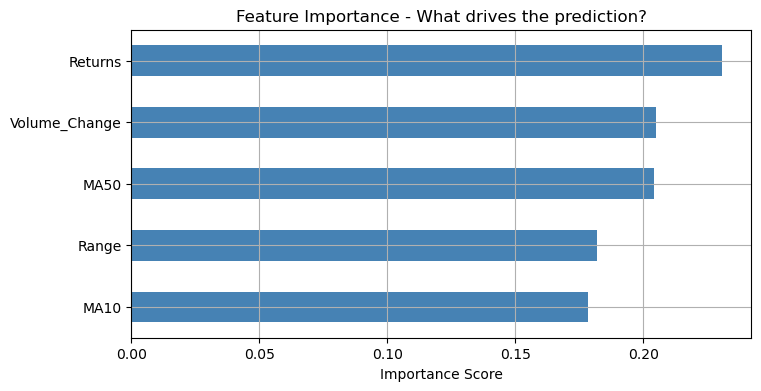

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the model
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

# Plot it
importance.plot(kind="barh", figsize=(8, 4), color="steelblue")
plt.title("Feature Importance - What drives the prediction?")
plt.xlabel("Importance Score")
plt.grid(True)
plt.show()

In [35]:
# Add predictions to test data for comparison
results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = y_pred

# Count correct vs wrong predictions
print("Prediction breakdown:")
print(results.groupby(["Actual", "Predicted"]).size())

Prediction breakdown:
Actual  Predicted
0       0             3
        1            41
1       0             6
        1            61
dtype: int64


In [39]:
code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

st.title("📈 Stock Price Analysis & Prediction Dashboard")
st.sidebar.header("Settings")

# Sidebar inputs
ticker = st.sidebar.text_input("Stock Ticker", value="AAPL")
start_date = st.sidebar.date_input("Start Date", value=pd.to_datetime("2022-01-01"))
end_date = st.sidebar.date_input("End Date", value=pd.to_datetime("2024-12-31"))

# Load data
@st.cache_data
def load_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end)
    df.columns = df.columns.get_level_values(0)
    return df

stock = load_data(ticker, start_date, end_date)

# Feature engineering
stock["Returns"] = stock["Close"].pct_change()
stock["Range"] = stock["High"] - stock["Low"]
stock["MA10"] = stock["Close"].rolling(window=10).mean()
stock["MA50"] = stock["Close"].rolling(window=50).mean()
stock["MA200"] = stock["Close"].rolling(window=200).mean()
stock["Volume_Change"] = stock["Volume"].pct_change()
stock["Tomorrow"] = stock["Close"].shift(-1)
stock["Target"] = (stock["Tomorrow"] > stock["Close"]).astype(int)
stock_clean = stock.dropna()

# Section 1 - Price Chart
st.subheader("📊 Closing Price & Moving Averages")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stock_clean["Close"], label="Close Price", alpha=0.6)
ax.plot(stock_clean["MA50"], label="50-Day MA", color="orange")
ax.plot(stock_clean["MA200"], label="200-Day MA", color="red")
ax.legend()
ax.grid(True)
st.pyplot(fig)

# Section 2 - Key Stats
st.subheader("📋 Key Statistics")
col1, col2, col3, col4 = st.columns(4)
col1.metric("Current Price", f"${stock_clean['Close'].iloc[-1]:.2f}")
col2.metric("Average Price", f"${stock_clean['Close'].mean():.2f}")
col3.metric("Highest Price", f"${stock_clean['High'].max():.2f}")
col4.metric("Lowest Price", f"${stock_clean['Low'].min():.2f}")

# Section 3 - ML Model
st.subheader("🤖 ML Prediction Model")
features = ["Returns", "Range", "MA10", "MA50", "Volume_Change"]
X = stock_clean[features]
y = stock_clean["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

st.metric("Model Accuracy", f"{accuracy:.2%}")

# Tomorrow prediction
latest = stock_clean[features].iloc[-1].values.reshape(1, -1)
prediction = model.predict(latest)[0]
if prediction == 1:
    st.success("📈 Model predicts price will GO UP tomorrow")
else:
    st.error("📉 Model predicts price will GO DOWN tomorrow")

# Section 4 - Feature Importance
st.subheader("🔍 Feature Importance")
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
fig2, ax2 = plt.subplots(figsize=(8, 3))
importance.plot(kind="barh", ax=ax2, color="steelblue")
ax2.set_xlabel("Importance Score")
ax2.grid(True)
st.pyplot(fig2)
'''

# Save to file
with open("stock_dashboard.py", "w", encoding="utf-8") as f:
    f.write(code)

print("File saved! ✅")

File saved! ✅


In [43]:
import subprocess
subprocess.Popen(["streamlit", "run", "stock_dashboard.py"])

<Popen: returncode: None args: ['streamlit', 'run', 'stock_dashboard.py']>